# 05. Correlation & Multicollinearity Analysis

This notebook focuses on **correlation structure and multicollinearity** among features.

Objectives:
- Quantify linear correlations
- Identify redundant features
- Evaluate multicollinearity formally (VIF)
- Decide whether multicollinearity is harmful for the chosen models

**This analysis is critical for model reliability and interpretability.**

## 1. Load Clean Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3

engine = sqlite3.connect('wine_quality.db')
df = pd.read_sql('SELECT * FROM wine_cleaned', engine)

df.shape

(5320, 13)

## 2. Correlation Matrix

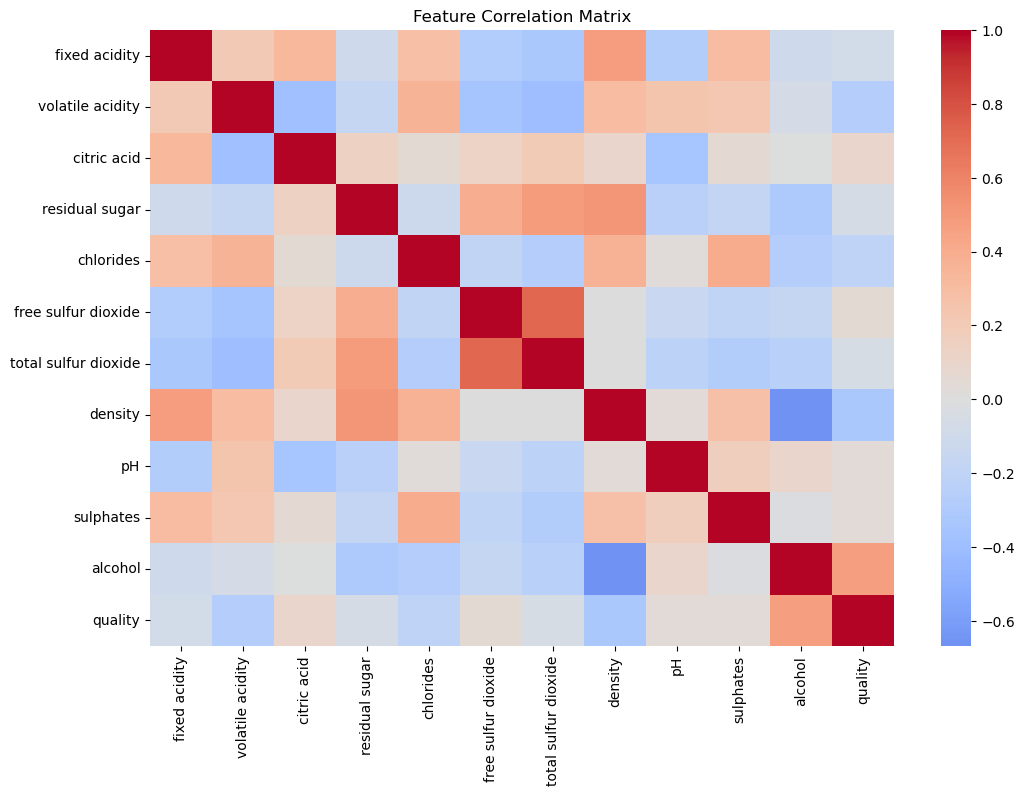

In [3]:
plt.figure(figsize=(12,8))
corr = df.drop(columns=['wine_type']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

### Observations
- Most feature pairs show weak correlations (< 0.3)
- A few moderate correlations exist (e.g., SO₂ related features)
- Linear correlation alone is insufficient for feature selection.

## 3. Highly Correlated Feature Pairs

In [6]:
threshold = 0.5
high_corr = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr.columns = ['feature_1', 'feature_2', 'correlation']
high_corr[high_corr['correlation'] >= threshold]

,feature_1,feature_2,correlation
33,residual sugar,density,0.520930
45,free sulfur dioxide,total sulfur dioxide,0.720488
58,density,alcohol,0.667811


### Observation
- Free sulfur dioxide and total sulfur dioxide are strongly correlated
- Indicates redundancy from a linear modeling perspective

## 4. Variance Inflation Factor (VIF)

VIF quantifies multicollinearity by measuring how much variance of a feature is inflated due to correlation with other features.

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop(columns=['quality', 'wine_type'])
X = X.assign(const=1)

vif_df = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif_df.sort_values('VIF', ascending=False)

,feature,VIF
11,const,1.629540e+06
7,density,1.492185e+01
3,residual sugar,6.428070e+00
0,fixed acidity,4.882077e+00
10,alcohol,4.575001e+00
6,total sulfur dioxide,2.932805e+00
8,pH,2.480073e+00
5,free sulfur dioxide,2.136488e+00
1,volatile acidity,1.957219e+00
2,citric acid,1.654623e+00


### observation
- Density is highly corelated with other featrures which means density is a redudant or derived feature.
- residual sugar,alcohol,fixed acidity are moderately co-related where there is no problem.
- Remaining all features are weakly co-related.

## 5. Summary

- All input features  exhibits mild-to-moderate co-related with target column (quality).
- Multi-collinearity strongly exists between only two features.
- In VIF concludes only density is a derived feature.
- Based on the analysis we decide which techniques are suitable for modelling along with metric choice.
